# 26회차 기출문제

## 문제 1

**Data description**

-   **Invoice_no** : 송장번호

-   **Stock_code** : 제품코드

-   **Stock_category** : 제품 분류

-   **Quantity** : 수량

-   **Invoice_date** : 주문일자

-   **Unit_price** : 단가

-   **Customer_id** : 고객번호

-   **Country** : 국가

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

In [92]:
dt1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/26/problem1.csv')
dt1.head(2)

EmptyDataError: No columns to parse from file

In [85]:
dt1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      1262 non-null   int64  
 1   id                              1262 non-null   object 
 2   Gender                          1262 non-null   object 
 3   Age                             1262 non-null   int64  
 4   Height                          1262 non-null   float64
 5   Weight                          1262 non-null   int64  
 6   family_history_with_overweight  1262 non-null   object 
 7   FAVC                            1262 non-null   object 
 8   FCVC                            1262 non-null   object 
 9   NCP                             1262 non-null   int64  
 10  CAEC                            1262 non-null   object 
 11  SMOKE                           1262 non-null   object 
 12  CH2O                            12

- 모델해석에 무의미한 변수 식별: Unnamed: 0, id(단순 식별자) → 삭제처리
- SCC 에 결측치 3개 식별 → 보간 또는 삭제

1.  **결측치 처리하시오.**

In [87]:
dt1.isna().sum()

Unnamed: 0                        0
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               3
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
BMI                               0
dtype: int64

In [3]:
dat.isnull().sum()

InvoiceNo         0
StockCode         0
StockCategory     0
Quantity         16
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

quantity 변수에 결측치 16개 존재한다.

먼저 year, month, day에 관한 날짜변수를 생성한다.

In [4]:
dat = dat.astype({'InvoiceDate' : 'datetime64[ns]', 'CustomerID' : 'object'})
dat['year'] = dat['InvoiceDate'].dt.year
dat['month'] = dat['InvoiceDate'].dt.month
dat['day'] = dat['InvoiceDate'].dt.day

결측치 대치를 위해 고객별 하루동안 구매한 quantity의 평균값을 산출한다.



In [5]:
mean_q = dat.groupby(['CustomerID', 'year', 'month', 'day']).agg(mean1 = ('Quantity', 'mean')).round(0).reset_index()
mean_q.head(2)

,CustomerID,year,month,day,mean1
0,12347,2010,12,7,10.0
1,12347,2011,1,26,11.0


In [6]:
dat = pd.merge(dat, mean_q, left_on = ["CustomerID", "year", "month", "day"], right_on = ["CustomerID", "year", "month", "day"], how = 'left')

특정 고객이 해당 제품을 몇 개를 살지 유추하기 어려우므로, 특정 고객이 그 날에 구매한 제품 quantity의 평균으로 결측치를 대치한

In [7]:
import warnings
warnings.filterwarnings('ignore')
dat['Quantity'][dat['Quantity'].isna()] = dat['mean1'][dat['Quantity'].isna()]

날짜 변수, 고객별 하루동안 구매한 quantity의 평균값은 제거한다.



In [8]:
dat = dat.drop(['mean1', 'year', 'month', 'day'], axis = 1)

In [9]:
dat.isna().sum()

InvoiceNo        0
StockCode        0
StockCategory    0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID       0
Country          0
dtype: int64

결측치가 대치된 것을 확인할 수 있다.



2.  **고객 데이터를 활용하여 군집분석을 수행하려고 한다. 군집분석 수행 전에 이상치를 제거하려고 한다. 이상치를 제거하는 방법을 설명하고, 이상치를 제거한 후 이상치가 모두 제거되었다는 통계 자료를 제시하시오.**

In [10]:
dat.describe()

,Quantity,UnitPrice
count,44416.000000,44416.000000
mean,20.158704,5.135913
std,48.147072,57.720402
min,-624.000000,0.000000
25%,4.000000,1.250000
50%,10.000000,1.950000
75%,16.000000,3.750000
max,2400.000000,4161.060000


quantity가 0 이하인 값이 존재한다. quantity가 음수의 값이 나올 수 없으므로 이상치로 판단하고 제거한다.

unit price가 0인 값이 존재한다.

In [11]:
dat.loc[dat.UnitPrice == 0, ['StockCode', 'StockCategory']]

,StockCode,StockCategory
452,22619,SET OF 6 SOLDIER SKITTLES
923,23234,BISCUIT TIN VINTAGE CHRISTMAS
1188,22385,JUMBO BAG SPACEBOY DESIGN
7612,22423,REGENCY CAKESTAND 3 TIER
9938,23157,SET OF 6 NATIVITY MAGNETS
14182,M,Manual
27312,M,Manual
29220,22841,ROUND CAKE TIN VINTAGE GREEN
35511,23270,SET OF 2 CERAMIC PAINTED HEARTS
35512,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER


In [12]:
dat.loc[dat.StockCode == '22619', ['StockCode', 'StockCategory', 'UnitPrice']]

,StockCode,StockCategory,UnitPrice
111,22619,SET OF 6 SOLDIER SKITTLES,3.75
150,22619,SET OF 6 SOLDIER SKITTLES,3.75
200,22619,SET OF 6 SOLDIER SKITTLES,3.39
365,22619,SET OF 6 SOLDIER SKITTLES,3.39
440,22619,SET OF 6 SOLDIER SKITTLES,3.39
452,22619,SET OF 6 SOLDIER SKITTLES,0.00
796,22619,SET OF 6 SOLDIER SKITTLES,3.39
2063,22619,SET OF 6 SOLDIER SKITTLES,3.75
2899,22619,SET OF 6 SOLDIER SKITTLES,3.75
3920,22619,SET OF 6 SOLDIER SKITTLES,3.75


제품코드, 제품분류가 같아도 단가가 다른 경우가 존재한다. unit price가 0인 경우는 사은품으로 증정해주는 경우를 생각해볼 수 있으므로, 이상치로 판단하지 않고 분석에 활용한다.

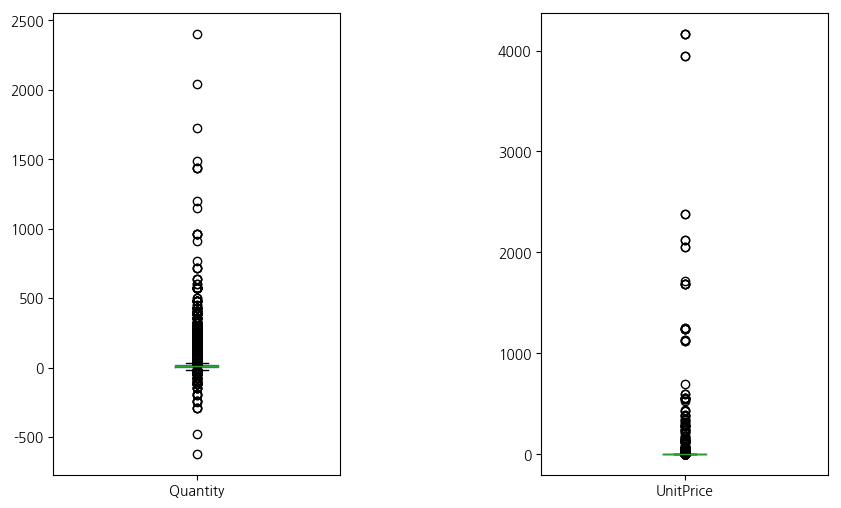

In [13]:
dat.loc[:, ['Quantity', 'UnitPrice']].plot(
    kind='box', 
    subplots=True, 
    sharey=False, 
    figsize=(10, 6)
);

plt.subplots_adjust(wspace=0.7);
plt.show();

In [14]:
Q1 = np.quantile(dat['Quantity'], 0.25)
Q3 = np.quantile(dat['Quantity'], 0.75)
IQR = Q3 - Q1

UC = Q3 + (1.5 * IQR) 
LC = Q3 - (1.5 * IQR) 

dat.loc[(dat.Quantity > UC), "Quantity"].describe()

count    5056.000000
mean      103.483188
std       108.429197
min        36.000000
25%        48.000000
50%        72.000000
75%       120.000000
max      2400.000000
Name: Quantity, dtype: float64

In [15]:
Q1 = np.quantile(dat['UnitPrice'], 0.25)
Q3 = np.quantile(dat['UnitPrice'], 0.75)
IQR = Q3 - Q1

UC = Q3 + (1.5 * IQR) 
LC = Q3 - (1.5 * IQR) 

dat.loc[(dat.UnitPrice > UC), "UnitPrice"].describe()

count    5458.000000
mean       26.557292
std       163.024353
min         7.650000
25%         8.500000
50%         9.950000
75%        16.950000
max      4161.060000
Name: UnitPrice, dtype: float64

다음으로 이상치 탐지 방법으로 상자 수염 그림을 이용해보고자 한다. 상자그림에서 이상치는 울타리를 기준으로 이상치를 판단하는데, 위 울타리는 제3사분위수 + 1.5xIQR, 아래 울타리는 제 1사분위수 - 1.5xIQR로 정의된다. 울타리를 기준으로 이상치를 탐색해보면 분포의 치우침으로 인해서 너무 많은 관측치가 이상치로 탐지되는 것을 확인할 수 있다.

단순히 이상치를 생각해보았을 때, unit price, quantity 값이 큰 관측치의 경우 충성고객 or 우량 고객일 가능성이 높다. 따라서 상자그림을 통해 이상치는 제거하지 않고, quantity < 0인 관측치만 이상치로 분류한 후 제거한다.

In [16]:
dat = dat.loc[dat.Quantity > 0, :]
dat.Quantity.describe()

count    43156.000000
mean        21.035638
std         48.198779
min          1.000000
25%          6.000000
50%         12.000000
75%         18.000000
max       2400.000000
Name: Quantity, dtype: float64

quantity < 0인 이상치가 제거된 것을 확인할 수 있다.



3.  **kmeans 또는 DBSCAN 등의 기법을 활용하여 군집을 생성하시오.**

In [17]:
# 고객별 총 거래 빈도(new_f)에 관한 파생변수를 생성한다.
new_f = dat.groupby(['CustomerID']).agg(new_f = ('CustomerID', 'count')).reset_index()
# 고객별 총 구매액(new_m)에 관한 파생변수를 생성한다.
new_m = dat.assign(t_price = lambda x: x.UnitPrice*x.Quantity).groupby(['CustomerID']).agg(new_m = ('t_price', 'sum')).reset_index()

# 군집분석을 위한 최종 데이터는 다음과 같다.
dat2 = pd.merge(new_f, new_m, left_on = 'CustomerID', right_on = 'CustomerID', how = 'inner')
dat2 = dat2.astype({'CustomerID' : 'object'})
dat2.head()

,CustomerID,new_f,new_m
0,12347,182,4310.00
1,12348,31,1797.24
2,12349,73,1757.55
3,12350,17,334.40
4,12352,85,2506.04


K-means 군집분석을 실시한다. k-means 군집분석을 실시하기 전 변수 간 스케일을 통일하고, 각 변수의 중요도를 균든하게 반영하기 위해 표준화를 진행한다.

In [18]:
from sklearn.preprocessing import StandardScaler
numeric_data = dat2.select_dtypes('number')
stdscaler = StandardScaler()
numeric_df = pd.DataFrame(stdscaler.fit_transform(numeric_data), columns = numeric_data.columns)
numeric_df.head(2)

,new_f,new_m
0,0.242606,0.023383
1,-0.234756,-0.118031


적절한 군집의 수를 정하기 위해 실루엣 계수를 활용한다.



In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
for i in range(2,10):
    fit_kmeans = KMeans(n_clusters=i, init='random', n_init = 10, random_state=0).fit(numeric_df)
    score = silhouette_score(numeric_df, fit_kmeans.labels_)
    scores.append(score)
    print("For n_clusters={0}, the silhouette score is {1}".format(i, score))

For n_clusters=2, the silhouette score is 0.9639191618105983
For n_clusters=3, the silhouette score is 0.7251022158137324
For n_clusters=4, the silhouette score is 0.5975615379076885
For n_clusters=5, the silhouette score is 0.5994298150983463
For n_clusters=6, the silhouette score is 0.5459473765982441
For n_clusters=7, the silhouette score is 0.5218054091630446
For n_clusters=8, the silhouette score is 0.4915640209536934
For n_clusters=9, the silhouette score is 0.46717873003782057


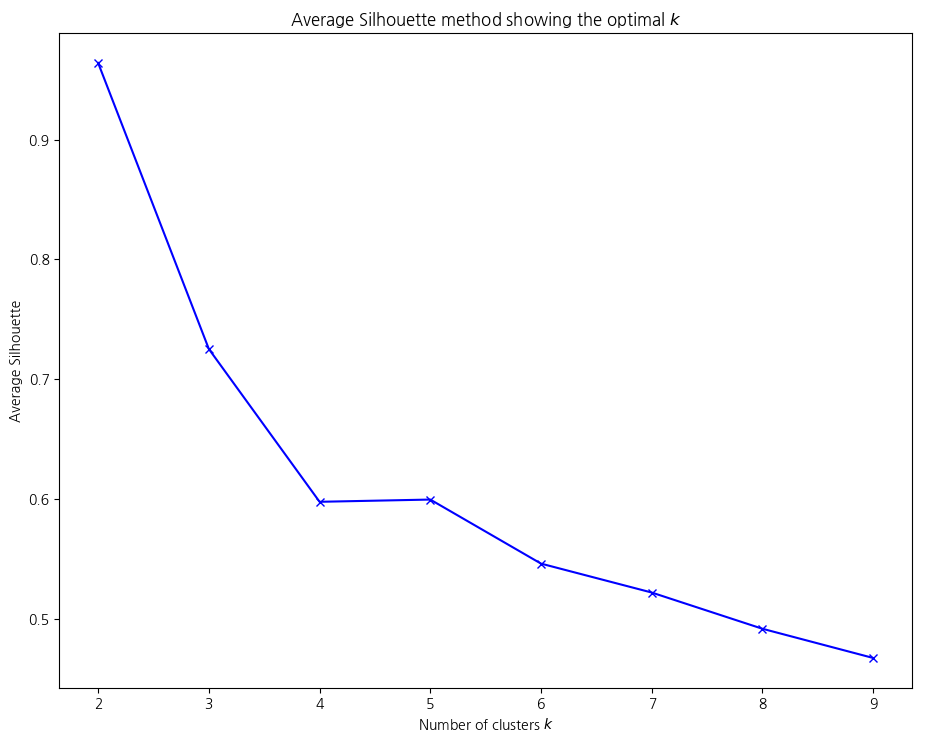

In [20]:
plt.figure(figsize=(11,8.5));
plt.plot(range(2,10), np.array(scores), 'bx-');
plt.xlabel('Number of clusters $k$');
plt.ylabel('Average Silhouette');
plt.title('Average Silhouette method showing the optimal $k$');
plt.show();

실루엣 계수로 구한 최적 군집의 수(k)는 2이다.

In [21]:
kmeans = KMeans(n_clusters = 2, random_state=0)
kmeans.fit(numeric_df)

KMeans(n_clusters=2, random_state=0)

dbscan의 경우 군집의 수를 사전에 지정할 수 없다. 군집결과를 해석하여 고객군을 분류하는 것이 목적이므로, 사전에 군집의 수를 적절하게 정할 수 있는 k-means 군집분석을 실시하였다.

4.  **생성된 군집에 대하여 군집성능지표를 산출하고, 군집간 차이와 특성을 분석한 결과를 제시하시오.**

Average silhouette method를 통해 응집도, 분리도 측면에서 최적의 k를 선택하고자 한다. Average silhouette method는 각 
별 평균 silhouette coefficient를 계산하고, 평균 silhouette coefficient값이 가장 큰 
를 선택하는 방법이다. 개별 관측치의 silhouette coefficient는 seperation, compactness를 동시에 고려하여 정의된다. k = 2일 때, Average silhouette coefficient = 0.9 이상으로 가장 높은 것을 확인할 수 있다.

In [22]:
label = kmeans.labels_
dat2['cluster'] = label

dat2['cluster'].value_counts()

0    408
1      2
Name: cluster, dtype: int64

0번 군집에 406명, 1번 군집에 4명이 묶인 것을 확인할 수 있다.



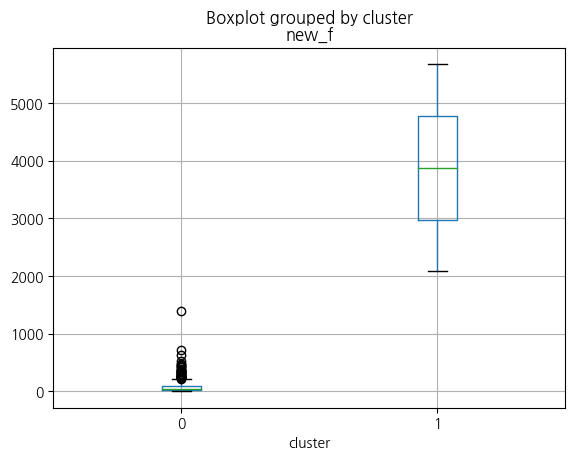

In [23]:
dat2.boxplot(column = ['new_f'], by = 'cluster');
plt.show();

In [24]:
pd.options.display.max_columns = None 
dat2.groupby(['cluster'])['new_f'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,408.0,86.762255,120.817688,1.0,21.75,45.0,101.50,1400.0
1,2.0,3878.500000,2543.463092,2080.0,2979.25,3878.5,4777.75,5677.0


고객별 총 거래빈도가 높은 군집은 1번 군집이다.

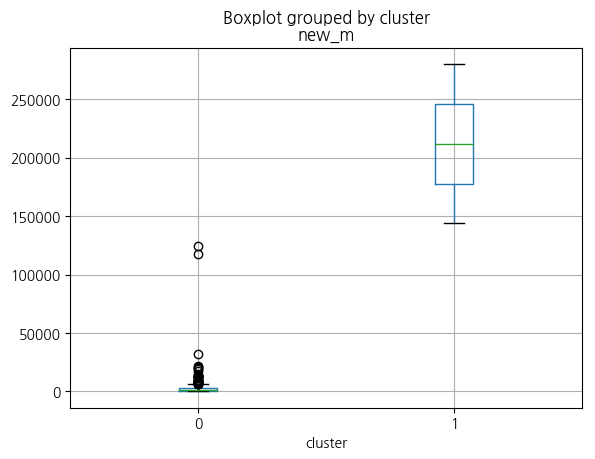

In [25]:
dat2.boxplot(column = ['new_m'], by = 'cluster');
plt.show();

In [26]:
dat2.groupby(['cluster'])['new_m'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,408.0,2874.317206,9017.627930,51.56,460.15,1031.995,2715.885,124798.53
1,2.0,212015.540000,96435.901641,143825.06,177920.30,212015.540,246110.780,280206.02


고객별 총 구매액이 높은 군집도 1번 군집이다.

5.  **군집별로 대표적인 추천상품을 구성하고, 군집별 추천 상품을 제시하고, 타군집과의 추천상품 차이를 설명하시오.**

In [27]:
dat = pd.merge(dat, dat2, left_on = ["CustomerID"], right_on = ["CustomerID"], how = 'left')

각 군집별 가장 많이 구매한 제품 top 5를 구한다. 군집 0번의 top5 상품은 다음과 같다.



In [28]:
result = dat.groupby(['cluster', 'StockCategory']).agg(count = ('StockCategory', 'count')).reset_index()
result

,cluster,StockCategory,count
0,0,4 PURPLE FLOCK DINNER CANDLES,1
1,0,50'S CHRISTMAS GIFT BAG LARGE,10
2,0,DOLLY GIRL BEAKER,26
3,0,I LOVE LONDON MINI BACKPACK,11
4,0,NINE DRAWER OFFICE TIDY,4
...,...,...,...
4686,1,ZINC SWEETHEART WIRE LETTER RACK,1
4687,1,ZINC T-LIGHT HOLDER STAR LARGE,4
4688,1,ZINC T-LIGHT HOLDER STARS SMALL,7
4689,1,ZINC WILLIE WINKIE CANDLE STICK,6


In [29]:
(result
        .loc[result.cluster == 0, :]
        .sort_values(by = ['count'], ascending=False)
        .iloc[:5, :]
)

,cluster,StockCategory,count
1774,0,POSTAGE,1056
1968,0,ROUND SNACK BOXES SET OF4 WOODLAND,275
1885,0,REGENCY CAKESTAND 3 TIER,235
1744,0,PLASTERS IN TIN WOODLAND ANIMALS,198
1739,0,PLASTERS IN TIN CIRCUS PARADE,180


군집 1번의 top5 상품은 다음과 같다.



In [30]:
(result
        .loc[result.cluster == 1, :]
        .sort_values(by = ['count'], ascending=False)
        .iloc[:5, :]
)

,cluster,StockCategory,count
2988,1,CARRIAGE,84
4090,1,REGENCY CAKESTAND 3 TIER,59
3833,1,PACK OF 72 RETROSPOT CAKE CASES,36
4239,1,SET OF 3 REGENCY CAKE TINS,36
4590,1,WHITE HANGING HEART T-LIGHT HOLDER,35


In [31]:
c0 = (result
        .loc[result.cluster == 0, :]
        .sort_values(by = ['count'], ascending=False)
        .iloc[:5, 1]
)

c1 = (result
        .loc[result.cluster == 1, :]
        .sort_values(by = ['count'], ascending=False)
        .iloc[:5, 1]
)

c_merge = pd.concat([c0, c1],axis=0)

(dat
    .loc[dat.StockCategory.isin(c_merge)]
    .groupby(['cluster'])
    .agg({'UnitPrice' : 'mean'})
)

,UnitPrice
cluster,
0,14.059467
1,16.931713


각 군집별 대표상품에 대해 제품 단가를 기준으로 보면 평균적으로 군집 1 > 군집 0인 것을 확인할 수 있다

6.  **KNN을 활용하여 고객별 근접이웃분석을 수행하고 상품추천을 수행하는 방법을 기술하고, 구현하시오.**

예시로 고객번호 “12347”에 대한 대표 상품을 구한다. 첫 번째로, KNN을 이용해서 고객별 근접 이웃을 정의한다.

In [32]:
(dat2
   .loc[dat2['CustomerID'] == 12347, ['cluster']]
)

,cluster
0,0


“12347” 고객은 0번 군집에 속해있다.



In [33]:
knndat = dat2.loc[dat.cluster == 0, :]
knndat2 = knndat.loc[:, ['new_f', 'new_m']]

new_f, new_m 변수를 활용하여 각 고객별 최근접이웃을 정의한다.



In [34]:
from sklearn.neighbors import NearestNeighbors 
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(knndat2)

In [35]:
distances, indices = neighbors_fit.kneighbors(knndat2)

ind = indices.reshape(-1)
indices2 = knndat.CustomerID     [ind].to_numpy().reshape(-1, 5)
result2 = pd.DataFrame(indices2, columns = ['k1','k2','k3', 'k4', 'k5'])
result2.index = knndat.CustomerID
result2

,k1,k2,k3,k4,k5
CustomerID,,,,,
12347,12347,14016,13505,12712,14277
12348,12348,14935,12424,17828,12645
12349,12349,12645,12424,12523,12407
12350,12350,12489,12519,12790,12527
12352,12352,12483,12455,12600,12397
...,...,...,...,...,...
17444,17444,12438,12408,12670,12685
17508,17508,13817,12690,13919,12515
17828,17828,14934,12381,12348,12383


“12347” 고객의 최근접 이웃이 자주 구매하는 top5 상품을 구한다.



In [36]:
(dat
    .loc[dat.CustomerID     .isin([12500, 12524, 12449, 12484])]
    .groupby(['StockCategory'])
    .agg(count = ('StockCategory', 'count'))
    .sort_values(by = ['count'], ascending=False)
    .reset_index()
)

,StockCategory,count
0,POSTAGE,25
1,SPACEBOY LUNCH BOX,6
2,ROUND SNACK BOXES SET OF4 WOODLAND,5
3,LUNCH BAG RED RETROSPOT,5
4,LUNCH BAG WOODLAND,5
...,...,...
484,"GREETING CARD, TWO SISTERS.",1
485,"GREETING CARD, STICKY GORDON",1
486,GRAND CHOCOLATECANDLE,1
487,GLASS JAR ENGLISH CONFECTIONERY,1


해당 상품을 “12347” 고객에게 추천한다.




## 문제 2 (25회 기출)

**Data description**

우리나라에 입국한 관광객 수에 관한 데이터입니다.

-   train : 1981.1 \~ 1991.12
-   test : 1992.1 \~ 1992.12

In [460]:
dt2= pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/26/problem2.csv')
display(dt2.head(3))

,index,value
0,1981 Jan,67745.0
1,1981 Feb,68478.0
2,1981 Mar,85521.0


In [461]:
dt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   144 non-null    object 
 1   value   140 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


데이터 정보 상으로 4개의 결측치가 존재하는 것 확인, index 컬럼은 날짜(년월) 형식으로 변환 필요

| 디렉티브  | 의미                                  | 예시                                   |
| ----- | ----------------------------------- | ------------------------------------ |
| `%a`  | 요일의 약어 (지역 설정 기준)                   | Sun, Mon … / So, Mo …                |
| `%A`  | 요일의 전체 이름 (지역 설정 기준)                | Sunday, Monday … / Sonntag, Montag … |
| `%w`  | 요일 (숫자, 일요일=0, 토요일=6)               | 0 \~ 6                               |
| `%d`  | 일 (2자리, 0으로 채움)                     | 01 \~ 31                             |
| `%b`  | 월 약어 (지역 설정 기준)                     | Jan, Feb … / Jan, Feb …              |
| `%B`  | 월 전체 이름 (지역 설정 기준)                  | January … / Januar …                 |
| `%m`  | 월 (2자리 숫자)                          | 01 \~ 12                             |
| `%y`  | 연도 (세기 제외, 2자리)                     | 00 \~ 99                             |
| `%Y`  | 연도 (세기 포함, 4자리)                     | 0001 \~ 9999                         |
| `%H`  | 시간 (24시간제, 2자리)                     | 00 \~ 23                             |
| `%I`  | 시간 (12시간제, 2자리)                     | 01 \~ 12                             |
| `%p`  | 오전/오후 (AM/PM, 지역 설정 기준)             | AM, PM / am, pm                      |
| `%M`  | 분 (2자리)                             | 00 \~ 59                             |
| `%S`  | 초 (2자리)                             | 00 \~ 59                             |
| `%f`  | 마이크로초 (6자리)                         | 000000 \~ 999999                     |
| `%z`  | UTC 오프셋 (±HHMM 또는 ±HHMMSS.ffffff)   | +0900, -0400, +063415                |
| `%Z`  | 시간대 이름                              | UTC, GMT 등                           |
| `%j`  | 연중 몇 번째 날인지                         | 001 \~ 366                           |
| `%U`  | 주 번호 (일요일 시작, 주 0부터)                | 00 \~ 53                             |
| `%W`  | 주 번호 (월요일 시작, 주 0부터)                | 00 \~ 53                             |
| `%c`  | 날짜와 시간 표현 (지역 설정 기준)                | Tue Aug 16 21:30:00 1988             |
| `%x`  | 날짜 표현 (지역 설정 기준)                    | 08/16/88, 16.08.1988                 |
| `%X`  | 시간 표현 (지역 설정 기준)                    | 21:30:00                             |
| `%%`  | 문자 `%` 자체                           | %                                    |
| `%G`  | ISO 8601 연도 (주 기준 연도)               | 2023, 2024 …                         |
| `%u`  | ISO 요일 (월=1, 일=7)                   | 1 \~ 7                               |
| `%V`  | ISO 주 번호 (월요일 시작, 주 1은 1월 4일 포함한 주) | 01 \~ 53                             |
| `%:z` | UTC 오프셋 (±HH\:MM)                   | +09:00, -04:00 등                     |


In [462]:
from datetime import datetime

dt2 = dt2.rename(columns = {'index':'date'})
dt2['date'] = pd.to_datetime(dt2['date'], format='%Y %b')
dt2['date'] = dt2['date'].dt.strftime('%Y-%m')
dt2 = dt2.set_index('date')
dt2.head(3)

,value
date,
1981-01,67745.0
1981-02,68478.0
1981-03,85521.0


1.  **데이터를 탐색하시오.**

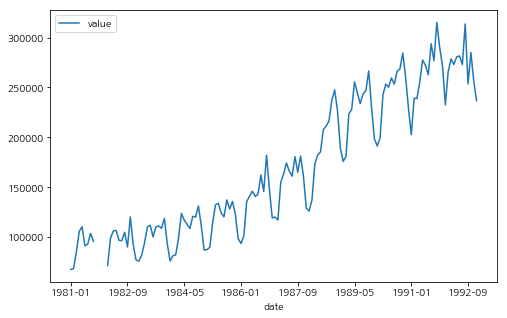

In [463]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, acf, pacf

dt2.plot(figsize=(8, 5))
plt.show()

plot과 dataframe을 통해 1981.10월 ~ 1982.1월 사이 결측치가 존재하는 것을 확인할 수 있다.
그리고 다음의 사항을 파악할 수 있다.

1. 추세(Trend) 명확한 증가 추세가 존재  
   시간의 흐름에 따라 전반적으로 값이 지속적으로 존재하고 있으며, 상승 폭이 점차 커지는 경향이 있음
2. 계절성(Seasonality): 1년을 주기로 반복되는 파형 구조 관찰됨  
   매년 비슷한 시점에 값이 상승하고, 다시 하락하는 구조를 보임
3. 분산: 분산이 시간에 따라 증가하고 있음 → 비정상 시계열 의심(분산이 일정하지 않으며 증가경향)
   초기에는 값의 진폭이 작지만, 후반으로 갈수록 진폭이 커지고 있음
   
**결론: 추세+계절성+증가하는 분산이므로 비정상 시계열로 보임(모델 학습 전 분석 수행)**  
분산이 일정하지 않으면 정상성(stationarity)을 만족하지 않으므로, 로그변환이나 차분(differencing)처리를  
고려해 볼 수 있음, ARIMA, SARIMA 모델을 적용하기 위해서는 정상화 처리가 필요함

2.  **결측치 확인 및 결측치를 대치하시오.**

In [464]:
dt2[dt2['value'].isna()]

,value
date,
1981-10,NaN
1981-11,NaN
1981-12,NaN
1982-01,NaN


In [465]:
dt2.head(-12)

,value
date,
1981-01,67745.0
1981-02,68478.0
1981-03,85521.0
1981-04,105884.0
1981-05,110425.0
...,...
1991-08,293781.0
1991-09,276797.0
1991-10,315219.0


In [466]:
test_size = 12 # 마지막 1년을 test
train, test = dt2.head(-test_size), dt2.tail(test_size)
train.shape, test.shape

((132, 1), (12, 1))

**선형 외삽(linear extrapolation)**: 결측값 주변의 관측값들 사이의 선형 관계를 기반으로 결측값을 추정하는 방법  
시계열 데이터의 **추세(trend)**를 반영할 수 있다는 장점이 있으며, 단순 평균이나 앞/뒤 값으로 대치하는 방법보다 시간에 따른 변화 양상을 고려할 수 있음

In [467]:
train['value'] = train['value'].interpolate(method='linear')

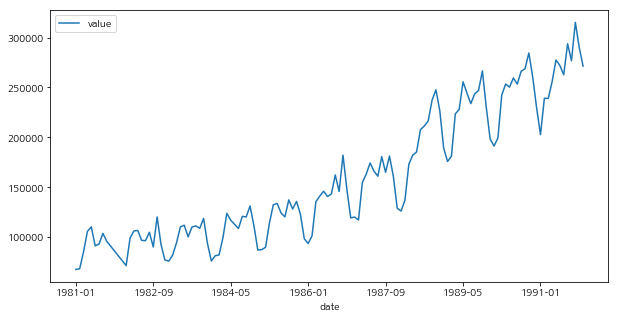

In [468]:
train.plot(figsize=(10, 5))
plt.show()

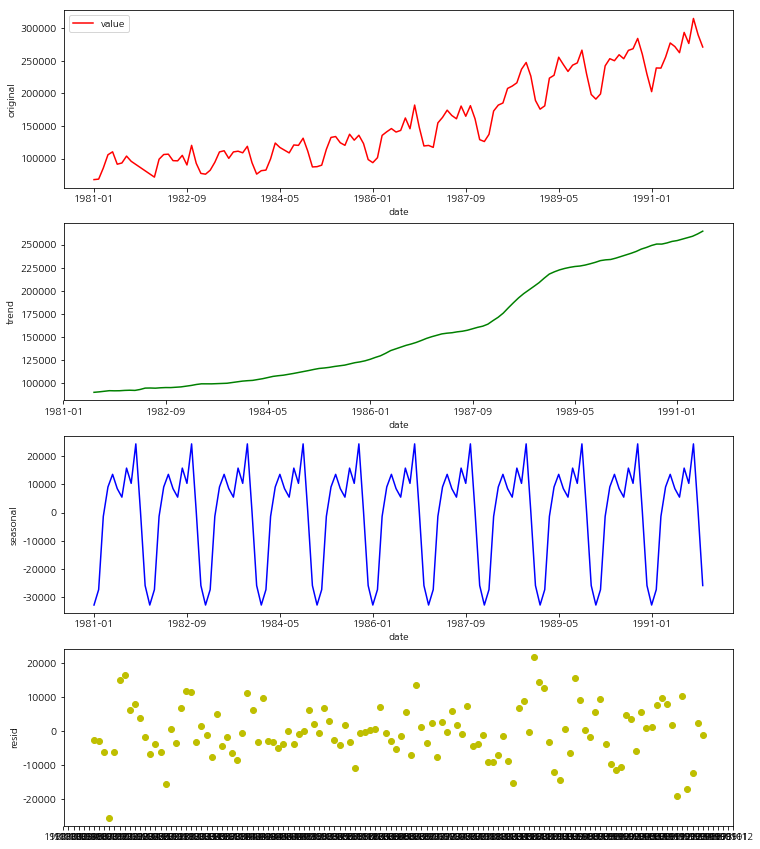

In [469]:
# 시계열 분해를 통해 추세, 계절성, 잔차 확인

from statsmodels.tsa.seasonal import seasonal_decompose

#seasonal(주기): 여기서는 년 주기(12개 데이터)로 확인(분기면 4)
fitted = seasonal_decompose(train, model='additive', period=12)
resid = fitted.resid #잔차
seasonal = fitted.seasonal #추정된 계절요소
trend = fitted.trend #추정된 트렌드 요소

title = ['original', 'trend', 'seasonal', 'resid']
dt_list = [train, trend, seasonal, resid]
co_list = ['r', 'g', 'b', 'y']

fig, ax = plt.subplots(4, 1, figsize=(12, 15))

for tt, data, ax, c in zip(title, dt_list, ax, co_list):
    if tt == 'resid':
        ax.scatter(x=data.index, y=data.values, color=c)
    else:
        data.plot(ax=ax, color=c)
    ax.set_ylabel(tt)
plt.show()

추세(trend), 계절성(seasonal), 잔차(resid) 로 시계열 데이터 분해를 통해 다음과 같은 사실을 확인할 수 있다.  
- 추세는 시간의 흐름에 따라 증가
- 일정한 파형의 계절성 추세가 있음
- 랜덤 노이즈 형태로 시간축을 따라 불규칙하게 분포

3.  **계절성을 포함하는 시계열 모델을 구축하고 정확도 측면에서 제시하시오.**

이 문제에서는 계절성과 추세를 모두 고려한 시계열 모델인 SARIMA를 활용한다.   
SARIMA 모델은 정상성(stationarity) 을 전제로 하므로, 모델 학습에 앞서 분산이 일정하지 않을 경우 로그 변환 등으로 분산을 안정화하고,  
**추세 및 계절성을 제거하기 위해 차분(일반 및 계절 차분)**을 수행한 후 정상성이 확보된 데이터로 모델을 학습한다.

**<처리방식>**

| **비정상성 유형**           | **특징**                | **처리 순서 / 방법**         | **사용 기법**                             |
| --------------------- | --------------------- | ---------------------- | ------------------------------------- |
| **추세 (Trend)**        | 평균이 시간에 따라 변함         | 차분 (특히 1차 차분)          | `.diff()`, `d=1` in ARIMA/SARIMA      |
| **분산 불균일 (이분산성)**     | 시간에 따라 데이터의 변동폭이 커짐   | 로그 변환 → 필요시 Box-Cox 변환 | `np.log()`, `scipy.stats.boxcox()`    |
| **계절성 (Seasonality)** | 일정 주기의 패턴 반복          | 계절 차분 먼저 → 이후 추세 차분    | `.diff(s)`, seasonal\_order in SARIMA |
| **비정상 전체**            | 추세 O + 계절성 O + 분산 불균일 | 로그 변환 → 계절 차분 → 1차 차분  | `log → diff(s) → diff(1)`             |
| **정상성 검정**            | 데이터가 안정적인 구조인지 확인     | ADF, KPSS 등 검정 수행      | `adfuller()`, `kpss()`                |


**<시계열 분석절차>**  

| **단계** | **설명**                          | **사용 기법**                              |
| ------ | ------------------------------- | -------------------------------------- |
| ①      | 시계열 plot 시각화 및 ACF/PACF 확인      | `plt.plot()`, `plot_acf`, `plot_pacf`  |
| ②      | 분산 불균일 시 **로그 변환**              | `np.log()`, `boxcox()`                 |
| ③      | **계절성 있으면 계절 차분 먼저**            | `.diff(s)`, `seasonal_order=(P,D,Q,s)` |
| ④      | **추세 남아있으면 일반 차분 추가**           | `.diff()`, `d=1`                       |
| ⑤      | 정상성 확인                          | `adfuller()`, `kpss()`                 |
| ⑥      | ACF/PACF로 `p`, `q`, `P`, `Q` 결정 | `plot_acf`, `plot_pacf`                |
| ⑦      | SARIMA 모델 학습                    | `SARIMAX()` from `statsmodels`         |
| ⑧      | 잔차 진단 (정상성, 백색잡음 여부)            | `Ljung-Box`, ACF of residuals          |


#### 1. 정상성 확인

<ADF 검정 가설수립>
- H0: 단위근이 있다.(비정상시계열)
- H1: 단위근이 없다.(정상시계열)

<KPSS 검정 가설수립>
- H0: 정상시계열이다.
- H1: 비정상시계열이다.

<ACF 그래프>  
- 정상데이터: 시차(Time lag)가 증가할수록 0으로 빠르게 떨어짐
- 비정상데이터: 시차(Time lag)가 증가할수록 느리게 감소

ADF 검정통계량: 1.186
p-value: 0.996
사용시차수: 13.000
관측개수: 118.000
유의수준 5% 하에서 귀무가설을 기각x(비정상)
--- kpss 검정 ---
ADF 검정통계량: 1.867
p-value: 0.010
유의수준 5% 하에서 귀무가설을 기각(비정상)


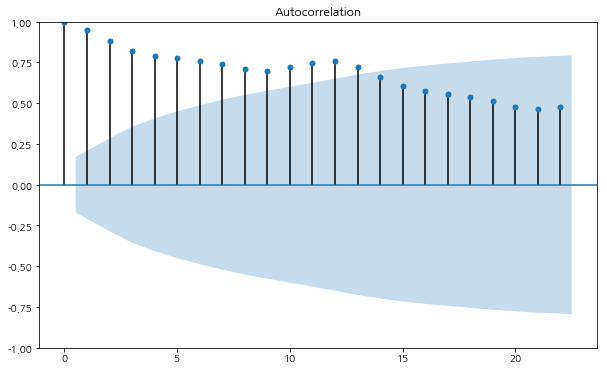

acf 그래프에서 시차에 증가에 따라 값이 천천히 감소하므로, 비정상 데이터


In [470]:
# null 값을 허용하지 않으므로, 계절성 고려하여 1983년부터의 데이터만으로 확인한다.
from statsmodels.tsa.stattools import adfuller, kpss

rs = adfuller(train, regression='c', autolag='AIC')

rs_title = ['ADF 검정통계량', 'p-value', '사용시차수', '관측개수']

for title, rsd in zip(rs_title, rs[:4]):
    print(f"{title}: {rsd:.3f}")

print("유의수준 5% 하에서 귀무가설을", "기각(정상)" if rs[1] < 0.05 else "기각x(비정상)")


#kpss 검정

rs2 = kpss(train, regression='c', nlags='auto')
print("-"*3, "kpss 검정", '-'*3)
for title, rsd in zip(rs_title[:2], rs2[:2]):
    print(f"{title}: {rsd:.3f}")
print("유의수준 5% 하에서 귀무가설을", "기각(비정상)" if rs2[1] < 0.05 else "기각x(정상시계열)")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_acf(train, ax=ax)
plt.show()

print('acf 그래프에서 시차에 증가에 따라 값이 천천히 감소하므로, 비정상 데이터')

In [471]:
#함수생성
from statsmodels.graphics.tsaplots import plot_pacf

def adf_check(data, text='', op=1):
    op_list = ['ADF', 'KPSS', 'ACF']
    if op == 1:
        rs = adfuller(data, regression='c', autolag='AIC')
        rs_title = [f'{op_list[op-1]} {text} 검정통계량', 'p-value', '사용시차수', '관측개수']
        for title, rsd in zip(rs_title, rs[:4]):
            print(f"{title}: {rsd:.3f}")
        print("유의수준 5% 하에서 귀무가설을", "기각(정상)" if rs[1] < 0.05 else "기각x(비정상)")
    elif op == 2:
        #kpss 검정
        rs = kpss(data, regression='c', nlags='auto')
        print("-"*3, "kpss 검정", '-'*3)
        for title, rsd in zip(rs_title[:2], rs[:2]):
            print(f"{title}: {rsd:.3f}")
        print("유의수준 5% 하에서 귀무가설을", "기각(비정상)" if rs[1] < 0.05 else "기각x(정상시계열)")
    elif op == 3:
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))
        plot_acf(data, lags=30, ax=ax)
        ax.set_title('ACF 그래프')
        plt.show()
    else:
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))
        plot_pacf(data, lags = 30, ax=ax)
        ax.set_title('PACF 그래프')
        plt.show()

시간에 따라 분산이 증가하는 경향이 있으므로, box-cox를 사용하여 데이터를 변환한다.  
- 다른기법: 로그변환, 제곱근변환, Yeo-Johnson
- 평균이 일정하지 않다면 데이터 차분 수행

시간에 따라 분산이 늘어나는 경향이 있으므로, 분산 안정화 변환을 실시한다.


In [472]:
#log 변환

train['value'] = np.log(train['value'])
test['value'] = np.log(test['value'])

print(train.head(1).values, test.head(1).values)

[[11.12350594]] [[12.35690784]]


STL 시계열 분해를 통해 계절성 추세가 확인되었기 때문에, 계절차분 수행 후 정상성이 여전히 확보되지 않으면 일반차분을 수행  
계절 차분 수행(계절주기: 12) 후 정상성 확인

In [473]:
s_diff1 = train.diff(12).dropna()
adf_check(s_diff1, '계절차분 후')

ADF 계절차분 후 검정통계량: -2.187
p-value: 0.211
사용시차수: 13.000
관측개수: 106.000
유의수준 5% 하에서 귀무가설을 기각x(비정상)


계절차분 수행 후 여전히 비정상 데이터이므로 1차 차분을 수행한다.

In [474]:
diff1 = s_diff1.diff(1).dropna()
adf_check(diff1, '1차 차분 후')

ADF 1차 차분 후 검정통계량: -5.087
p-value: 0.000
사용시차수: 13.000
관측개수: 105.000
유의수준 5% 하에서 귀무가설을 기각(정상)


1차 차분 이후 정상성을 만족한다. 그래프를 통해 비교해본다. 

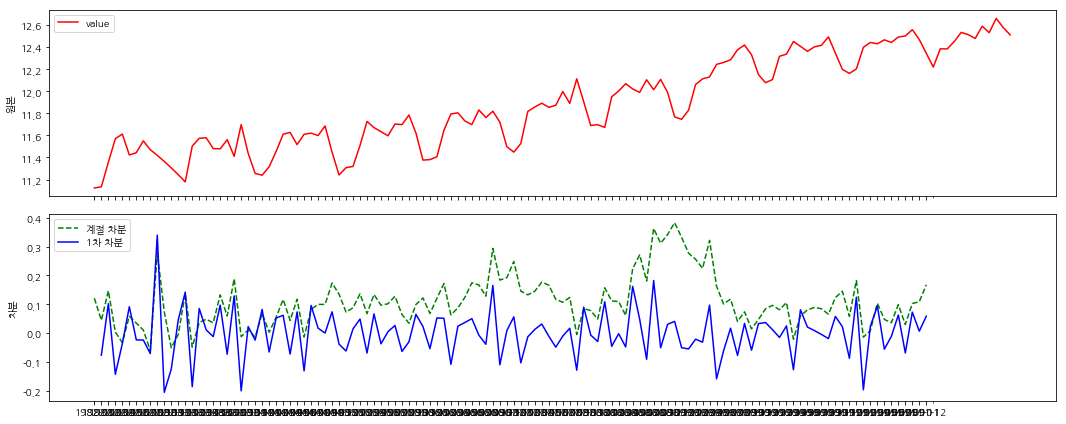

In [475]:
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# 1. 원본 데이터 plot (첫 번째 축)
train.plot(ax=ax[0], color='red', linestyle='solid', label='원본 데이터')
ax[0].set_ylabel("원본")

# 2. 차분 데이터 plot (두 번째 축)
dt_list = [s_diff1, diff1]
dt_title = ['계절 차분', '1차 차분']
colors = ['g', 'b']
styles = ['dashed', 'solid']

for dt, title, color, style in zip(dt_list, dt_title, colors, styles):
    ax[1].plot(dt, color=color, linestyle=style, label=title)
ax[1].legend(loc='upper left')
ax[1].set_ylabel("차분")

plt.tight_layout()
plt.show()

기존의 데이터에서 계절차분+1차 차분을 통해 정상성이 확보된 것을 확인할 수 있다.  
정상성이 확인된 상태에서 SARIMA 모델의 차수(p, d, q)를 결정하기 위해 ACF, PACF 그래프를 통해 자기상관을 확인한다.

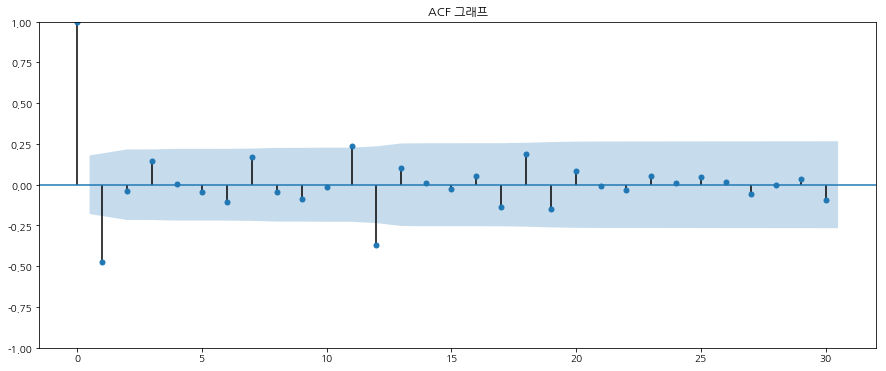

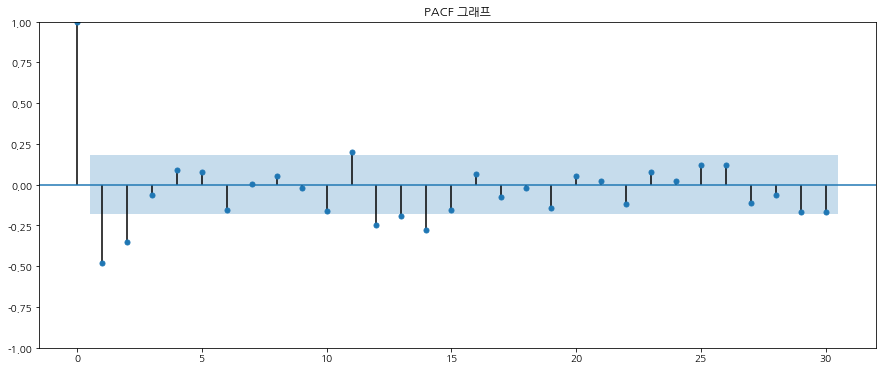

In [476]:
adf_check(diff1, op=3)
adf_check(diff1, op=4)

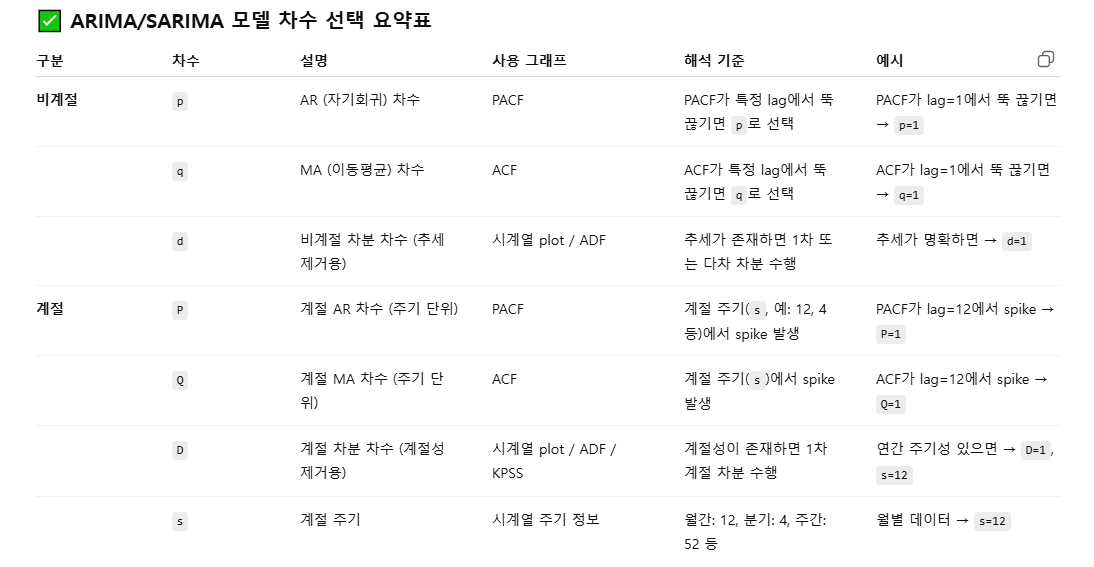

<비계절 차수>
- PACF 그래프에서 lag 2에서 절단 양상이 보이며, 이후 대체로 신뢰구간 내에 존재하므로 p=2로 설정
- ACF 그래프에서 lag 1에서 절단 양상이 보이며, 이후 대체로 신뢰구간 내에 존재하므로 q=1로 설정
- 1 차분 이후 정상성이 만족되었으므로 d = 1

<계절 차수>
- PACF 그래프에서 계절주기(s=12)의 배수구간에서 피크가 없으므로 P=0
- ACF 그래프에서 lag=1, 12에서 피크가 있고, 이후(24) 배수에서는 피크가 없으므로 Q=1
- 기존 데이터에서 계절성을 뚜렷하게 확인할 수 있었으며, 계절차분을 수행했으므로 D=1
- 월별 데이터이므로 s=12

In [477]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# model_list = pd.DataFrame(columns=['name', 'AIC', 'BIC'])

# for i in range(5):
#     t_model = SARIMAX(train, 
#                order=(i, 1, 1), 
#                seasonal_order=(0, 1, 1, 12), 
#                enforce_stationarity=False, 
#                enforce_invertibility=False)

#     rs = t_model.fit()
#     model_list.loc[len(model_list)] = [f"P:{i}", rs.aic, rs.bic]
# display(model_list.sort_values(by='AIC', ascending=False))

In [478]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, 
               order=(2, 1, 1), 
               seasonal_order=(0, 1, 1, 12), 
               enforce_stationarity=False, 
               enforce_invertibility=False)

rs = model.fit()

print(rs.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 158.627
Date:                            Thu, 17 Jul 2025   AIC                           -307.255
Time:                                    12:30:30   BIC                           -293.985
Sample:                                01-01-1981   HQIC                          -301.878
                                     - 12-01-1991                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1076      0.241     -4.596      0.000      -1.580      -0.635
ar.L2         -0.4667      0.112   

SARIMAX 모델 학습 결과이다. 비계절 차수를 (2,1,1), 계절차수를 (0,1,1,12)로 설정하였다. 

- Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아짐 158.627
- AIC(낮을수록 좋음): -307.255
- BIC(낮을수록 좋음, 모델 단순성까지 고려): -293.985
- 모수추정결과: 모든 항목이 유의수준 5% 하에서 0.05보다 작으므로 통계적으로 유의

| 계수         | 추정값    | P-value | 해석                                 |
|--------------|----------|---------|--------------------------------------|
| ar.L1        | -1.1076  | 0.000   | 유의미한 AR(1) 계수                  |
| ar.L2        | -0.4667  | 0.000   | 유의미한 AR(2) 계수                  |
| ma.L1        | 0.5736   | 0.026   | 유의미한 MA(1) 계수                  |
| ma.S.L12     | -0.4515  | 0.000   | 유의미한 계절 MA(12) 계수            |
| sigma2       | 0.0028   | 0.000   | 오차의 분산(낮을수록 예측이 정밀함)  |


- 잔차진단: 독립성, 정규성, 등분산성 만족
  - Ljung-Box: p-value 0.8로 잔차에 자기상관 없음
  - Jarque-Bera (JB): p-value 0.7로 잔차가 정규분포를 따름
  - Heteroskedasticity (H): p-value 0.34로 잔차의 분산이 일정함  
  
**해당 SARIMA 모델은 시계열 구조를 잘 포착하고 있으며, 예측에 적합한 모형**

----------
데이터셋: train set
MAE: 1.488
RMSE: 1.493
----------
데이터셋: test_set
MAE: 0.164
RMSE: 0.190


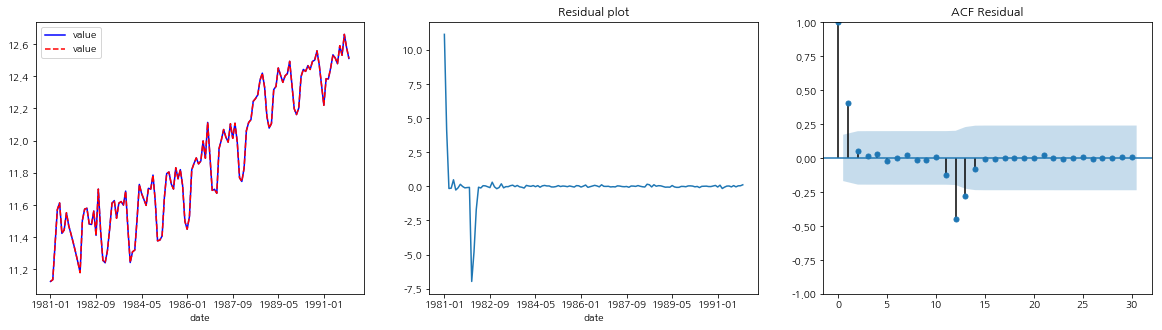

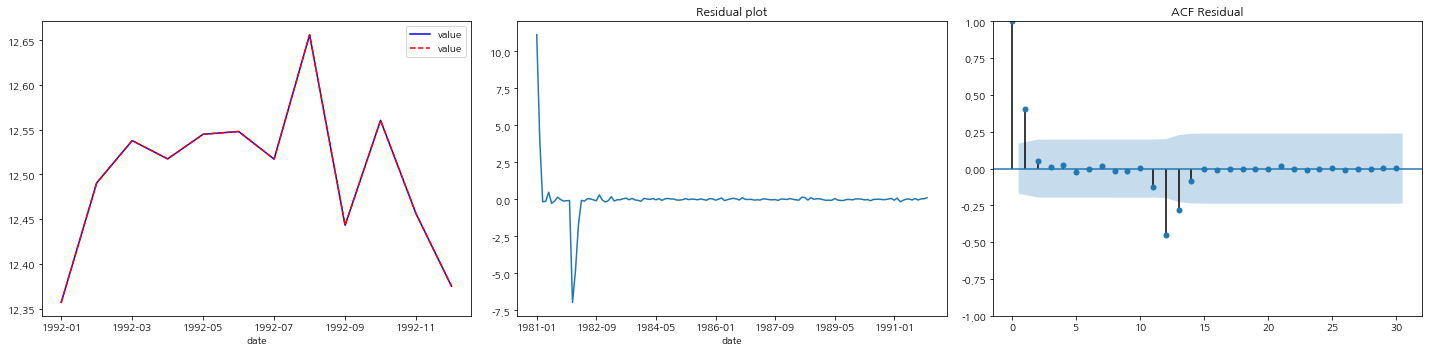

In [479]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

s_list = [['train set', train], ['test_set', test]]

for name, dt in s_list:
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    print('-'*10)
    print(f"데이터셋: {name}")
    forecast = rs.get_forecast(steps=len(dt))
    f_mean = forecast.predicted_mean
    MAE = mean_absolute_error(dt, f_mean)
    rmse = np.sqrt(mean_squared_error(dt, f_mean))
    print(f"MAE: {MAE:.3f}")
    print(f"RMSE: {rmse:.3f}")
    dt.plot(ax=ax[0], label='Actual', color='b') #실제값
    dt.plot(ax=ax[0], label='forecast', color='r', linestyle='dashed')
    #잔차플롯
    resid = rs.resid
    resid.plot(ax=ax[1], title='Residual plot')
    #잔차 acf plot
    plot_acf(resid, lags=30, ax=ax[2])
    ax[2].set_title('ACF Residual')
plt.tight_layout()
plt.show()

In [480]:
# auto arima 비교: p, q를 0~5까지 반복하여 최적의 모델 찾기
import pmdarima as pm
model2 = pm.auto_arima(train,
                       start_p=0, 
                       start_q=0, 
                       max_p=5, 
                       max_q =5, 
                       m = 12, 
                       d=1, 
                       seasonal=True, 
                       start_P=0, 
                       max_P = 5,
                       D=1,
                       trace=True, 
                       error_action='ignore', 
                       suppress_warnings=True, 
                       stepwise=True)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-282.638, Time=0.38 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-250.935, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-302.540, Time=0.42 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-318.098, Time=0.59 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-290.045, Time=0.24 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-317.983, Time=0.70 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-317.830, Time=0.97 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-317.285, Time=0.26 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-317.151, Time=2.49 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-316.294, Time=1.79 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-316.403, Time=1.51 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-305.334, Time=1.17 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-314.604, Time=1.20 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=-316.410, Time=0.52 sec

Best model:  ARIMA

ARIMA(0,1,1)(0,1,1)[12] 를 최종 모형으로 선택한다. 모델에 대한 가정을 검토한다.

In [481]:
from statsmodels.tsa.arima.model import ARIMA
model3 = ARIMA(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()
print(model3.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            value   No. Observations:                  132
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 162.049
Date:                          Thu, 17 Jul 2025   AIC                           -318.098
Time:                                  12:30:44   BIC                           -309.761
Sample:                              01-01-1981   HQIC                          -314.712
                                   - 12-01-1991                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6036      0.080     -7.592      0.000      -0.759      -0.448
ma.S.L12      -0.5751      0.102     -5.655      0.

auro arima를 통해 최적의 모델로 선정된 SARIMAX 모델 학습 결과이다. 비계절 차수를 (0,1,1), 계절차수를 (0,1,1,12)로 설정하였다. 

- Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아지며 162.049으로 이전 계수를 fix한 모델보다 성능이 좋다.
- AIC(낮을수록 좋음): -318.098 로 이전 모델보다 성능이 좋음
- BIC(낮을수록 좋음, 모델 단순성까지 고려): -309.761로 이전 모델보다 성능좋음
- 모수추정결과: 모든 항목이 유의수준 5% 하에서 0.05보다 작으므로 통계적으로 유의

| 계수         | 추정값    | P-value | 해석                                 |
|--------------|----------|---------|--------------------------------------|
| ma.L1        | 0.5736   | 0.026   | 유의미한 MA(1) 계수                  |
| ma.S.L12     | -0.4515  | 0.000   | 유의미한 계절 MA(12) 계수            |
| sigma2       | 0.0028   | 0.000   | 오차의 분산(낮을수록 예측이 정밀함)  |


- 잔차진단: 독립성, 정규성(x), 등분산성 만족
  - Ljung-Box: p-value 0.73로 잔차에 자기상관 없음
  - Jarque-Bera (JB): p-value 0.49로 잔차가 정규성을 따르지 않음
  - Heteroskedasticity (H): p-value 0로 잔차의 분산이 일정함

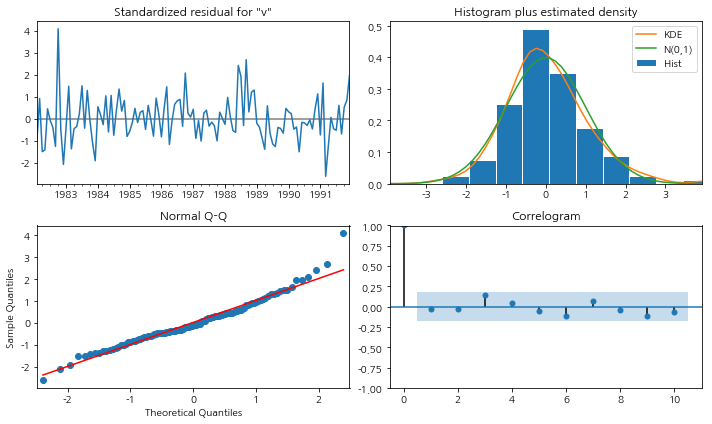

In [482]:
model3.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()

- Standardized residual plot (표준화 잔차): 잔차가 대체로 +-2 범위 내에 있으며, 시간에 따른 패턴 없음
- Histogram + KDE (정규성 확인): 정규분포에 가깝지만 약간 왼쪽으로 치우쳐있음(정규성 가정 약간 위반)
- Q-Q plot (정규성 정밀 진단): 대체로 직선 상에 분포하지만 상단에 벗어나는 점 존재
- Correlogram (잔차의 자기상관): 95% 신뢰구간 내 존재로 잔차의 유의미한 자기상관 없음

**약간의 정규성 위반은 관찰되나, 모델이 전반적으로 잘 적합되었고, 잔차에 큰 문제는 없으며 예측이 목적이라면 문제없음**

### 예측 성능 확인

훈련 데이터와 테스트 데이터의 모델 성능은 다음과 같다.

----------
데이터셋: train set
MAE: 1.379
RMSE: 1.382
----------
데이터셋: test_set
MAE: 0.144
RMSE: 0.168


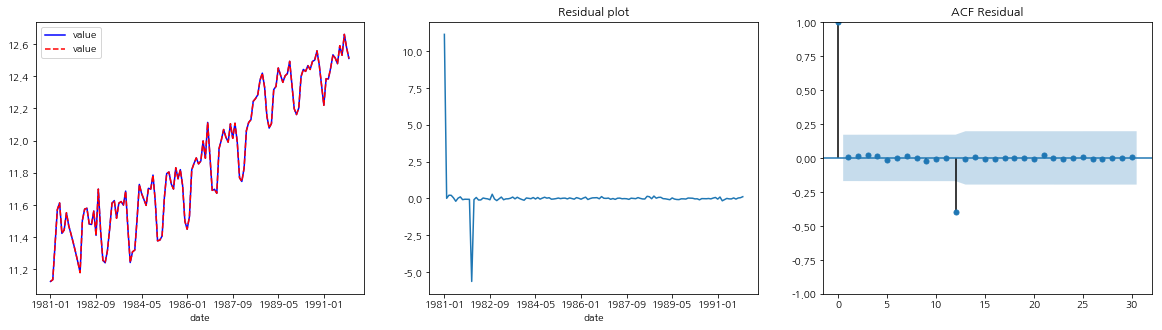

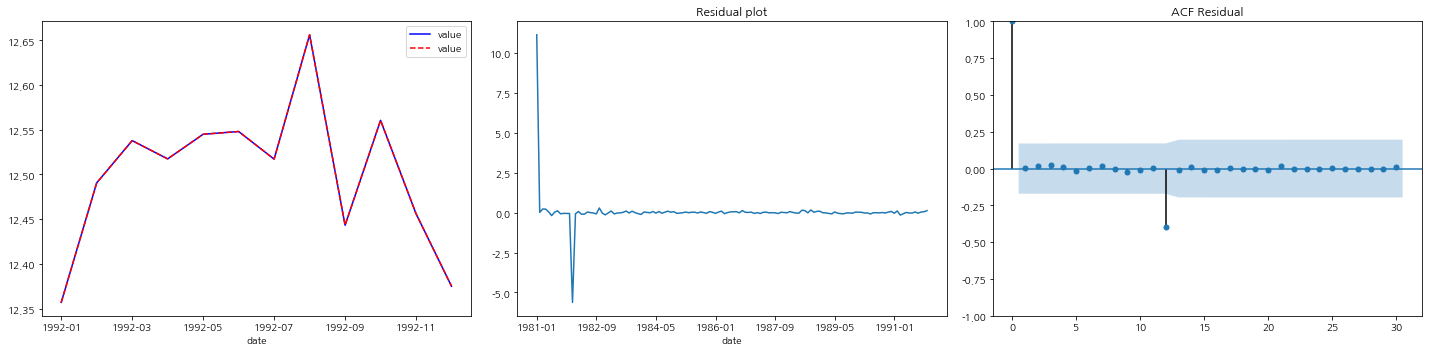

In [483]:
s_list = [['train set', train], ['test_set', test]]

for name, dt in s_list:
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    print('-'*10)
    print(f"데이터셋: {name}")
    forecast = model3.get_forecast(steps=len(dt))
    f_mean = forecast.predicted_mean
    MAE = mean_absolute_error(dt, f_mean)
    rmse = np.sqrt(mean_squared_error(dt, f_mean))
    print(f"MAE: {MAE:.3f}")
    print(f"RMSE: {rmse:.3f}")
    dt.plot(ax=ax[0], label='Actual', color='b') #실제값
    dt.plot(ax=ax[0], label='forecast', color='r', linestyle='dashed')
    #잔차플롯
    resid = model3.resid
    resid.plot(ax=ax[1], title='Residual plot')
    #잔차 acf plot
    plot_acf(resid, lags=30, ax=ax[2])
    ax[2].set_title('ACF Residual')
plt.tight_layout()
plt.show()

In [484]:
# train. test set 종합성능
def MASE(training_series, testing_series, prediction_series):
    n = training_series.shape[0]
    d = np.abs(np.diff( training_series) ).sum()/(n-1)
    errors = np.abs(testing_series - prediction_series )
    return errors.mean()/d


prediction = model3.predict(start=test.index[0], end=test.index[-1])
pred2 = rs.predict(start=test.index[0], end=test.index[-1])

print(MASE(train['value'].to_numpy(), test['value'].to_numpy(), prediction.to_numpy()))
print(MASE(train['value'].to_numpy(), test['value'].to_numpy(), pred2.to_numpy()))

1.526710653784624
1.748091031149483


### 실제값과 예측값 비교

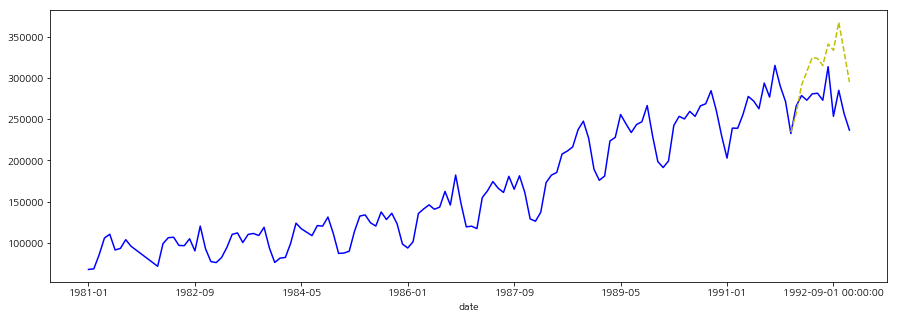

In [487]:
prediction = model3.predict(start=test.index[0], end=test.index[-1]) #예측값
prediction = np.exp(prediction)
et = pd.DataFrame(index = train.index, columns=['value'])
prediction = pd.concat([et, prediction], axis=0)

#실제값 원복
train['value'] = np.exp(train['value'])
test['value'] = np.exp(test['value'])
dt2 = pd.concat([train, test], axis=0)

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

dt2.plot(ax=ax, color='b', linestyle='solid', label='real', legend=False)
prediction.plot(ax=ax, color='y', linestyle='--', legend=False)
plt.show()

4.  **업무에 적용할 수 있는지, 판단근거와 함께 서술하시오.**

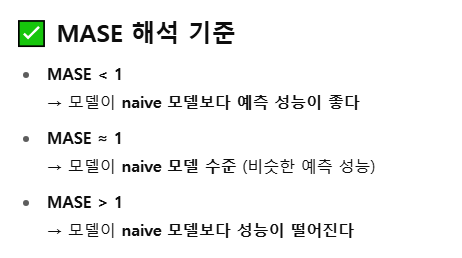

MASE 지표를 통해 모델의 실무 적용 가능성을 판단할 수 있다. MASE가 1보다 크다는 것은,   
학습 데이터에서 naive forecast(예: 이전 시점의 값 그대로 예측하는 단순 모델)보다 현재 모델의 예측 오차가 더 크다는 의미이다.

실제로 테스트 데이터 기준으로 계산한 MASE는 1.52로, 기준값인 1을 초과하였다.   
이는 새로운 데이터가 들어왔을 때 모델의 일반화 성능이 낮을 수 있음을 의미하며, 실무 적용에는 부적절하다는 결론을 도출할 수 있다.

따라서 해당 모형(SARIMA 등)을 그대로 사용하는 것보다는, LSTM, Prophet 등 다른 시계열 예측 모델을 대안으로 고려하는 것이 바람직하다.  
특히, 데이터에 비선형성이나 외부 요인이 영향을 줄 수 있다면 딥러닝 기반의 모델이 더 적합할 수 있다.

## 문제 3(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학 연구소에서 연구원으로 일하고 있습니다. 그는 직업 만족도가 사람들의 수입 수준에 따라 어떻게 달라지는지 궁금했습니다. 이를 위해 도시에서 일하는 96명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사에서는 응답자들의 수입과 직업 만족도에 대해 물어보았고, 그 결과는 다음과 같았습니다.

| 수입\직업만족도      | VD (매우 불만족) | LD (조금 불만족) | MS (조금 만족) | VS (매우 만족) |
| ------------- | :---------: | :---------: | :--------: | :--------: |
| <15,000       |      1      |      3      |     10     |      6     |
| 15,000-25,000 |      2      |      3      |     10     |      7     |
| 25,000-40,000 |      1      |      6      |     14     |     12     |
| >40,000       |      0      |      1      |      9     |     11     |


Goodman and Kruskal의 Gamma 계수는 두 순위형 변수 간의 순위일치(양의 순위쌍)와 불일치(음의 순위쌍)의 차이를 통해   
순위상관관계를 측정하는 통계량
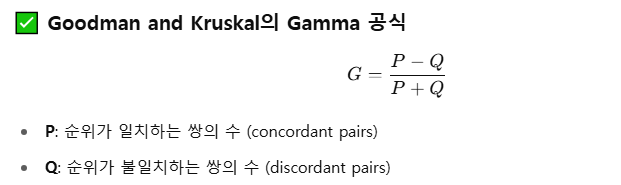

P: 두 쌍 비교 시 수입도 증가하고, 직업만족도도 증가하는 경우 쌍의 개수((1,1) 과 (2, 2) 쌍 비교)  
Q: 두 쌍 비교 시 수입은 증가하나, 직업만족도는 감소하는 경우 쌍의 개수((1, 2)와 (2, 1) 쌍 비교)

**<해석>**  
- 범위: -1 <= G <= 1
- 해석
  - G = 1: 완전한 순위 일치(강한 양의 상관관계)
  - G = -1: 완전한 순위 불일치(강한 음의 상관관계)
  - G = 0: 순위간 무상관(동점은 계산에서 제외)

1.  **수입 수준과 직업 만족도 간의 순위 관계를 파악하기 위해 Goodman and Kruskal의 Gamma 계수를 계산하시오.**

In [3]:
dd = np.array([
    [1, 3, 10, 6], 
    [2, 3, 10, 7], 
    [1, 6, 14, 12], 
    [0, 1, 9, 11]])
i_name = ['<15,000', '15,000-25,000', '25,000-40,000', '>40,000']
c_name = ['VD (매우 불만족)', 'LD (조금 불만족)', 'MS (조금 만족)', 'VS (매우 만족)']
dt3 = pd.DataFrame(dd, index=i_name, columns= c_name)
dt3

,VD (매우 불만족),LD (조금 불만족),MS (조금 만족),VS (매우 만족)
"<15,000",1,3,10,6
"15,000-25,000",2,3,10,7
"25,000-40,000",1,6,14,12
">40,000",0,1,9,11


In [18]:
from itertools import product

P = 0 #일치 쌍 수
Q = 0 #불일치 쌍 수

for (i1, j1), (i2, j2) in product(np.ndindex(dt3.shape), repeat=2):
    if (i1 < i2) & (j1 < j2):
        P += dt3.iloc[i1, j1] * dt3.iloc[i2, j2]
    elif (i1 < i2) & (j1 > j2):
        Q+= dt3.iloc[i1, j1] * dt3.iloc[i2, j2]

# Gamma 계산
G = (P - Q) / (P + Q)

print(f"순위 일치쌍 수: {P} / 불일치쌍 수: {Q}")
print(f"Goodman and Kruskal Gamman 계수: {G:.3f}")

순위 일치쌍 수: 1331 / 불일치쌍 수: 849
Goodman and Kruskal Gamman 계수: 0.221


Goodman and Kruskal Gamman 계수: 0.22로 약한 양의 상관관계가 있다.  
이는 수입수준이 높아질수록 직업 만족도가 다소 증가하는 경향이 있다는 것을 알 수 있다.  
하지만, 상관 정도가 강하지는 않기 때문에 다른 요인들도 직업 만족도에 영향을 미칠 가능성이 있다.

2.  **5% 유의수준
에서 가설 검증에 대한 검정통계량을 계산하시오. (단, 반올림하여 소수점 셋째 자리까지 표시하시오.) 연구가설의 채택여부를 결정하시오.**

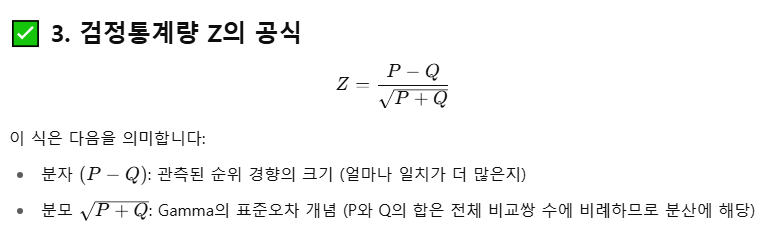


- H0: 두 변수 간에는 순위상관관계가 없다.(Gamma=0)
- H1: 두 변수 간에는 순위상관관계가 있다.(Gamma !=0)

In [44]:
from scipy.stats import norm
z = (P-Q)/np.sqrt(P+Q)
p_value = (1-norm.cdf(abs(z)))*2

print(f"z 검정통계량: {z:.3f} / p_value: {p_value:.3f} 이므로 귀무가설", "기각" if p_value < 0.05 else "채택")

z 검정통계량: 10.323 / p_value: 0.000 이므로 귀무가설 기각


In [47]:
# 책 공식 기반
z2 = G / np.sqrt((1-G**2)/(P+Q))
p_value2 = 2*norm.sf(abs(z2))
print(f"z 검정통계량: {z2:.3f} / p_value: {p_value2:.3f} 이므로 귀무가설", "기각" if p_value2 < 0.05 else "채택")

z 검정통계량: 10.585 / p_value: 0.000 이므로 귀무가설 기각


유의수준 5% 하에서 p-value = 0으로 크므로, 귀무가설을 기각한다.   
따라서, 수입수준이 높아질수록 직업 만족도가 다소 증가하는 경향이 있으며, 이는 통계적으로 유의하다.

| 공식                                       | 사용 전제         | 권장 상황                |
| ------------------------------------------ | ------------- | -------------------- |
| $Z = \frac{P - Q}{\sqrt{P + Q}}$           | P, Q 직접 계산 가능 | 통계 소프트웨어, 원래 정의 따를 때 |
| $Z = \frac{G}{\sqrt{\frac{1 - G^2}{N}}}$   | G만 있고 N만 알 때  | 계산 간편, 책이나 수식 위주 설명  |




## 문제 4

**별도의 데이터 없음**

슬통 전구회사는 자사의 제품 생산 라인에서 최근 불량률이 급증했다는 내부 보고서를 받았습니다. 초기 보고서에 따르면 불량률이 약 9%에 달한다고 합니다. 회사의 경영진은 이를 확인하기 위해 독립적인 품질 검사팀에 조사를 의뢰하였습니다. 검사팀은 신뢰도 95%로 불량률을 확인하기 위해 필요한 표본 크기를 계산하고자 합니다. 오차한계가 3% 내외로 허용된다면, 검사팀은 최소 몇 개의 제품을 표본으로 선택해야 하는지 계산하시오.

In [54]:
# 이항분포 모비율 추정의 표본갯수 문제
p = 0.09 # 추정 불량률
a = 0.05 #유의수준
z = norm.ppf(1-a/2) #신뢰도 95%에 해당하는 z값(단측)
e = 0.03 # 오차한계

v = p*(1-p) # 분산

n = np.ceil(v/np.square(e/z))

print(f"최소 {n} 개")

최소 350.0 개




## 문제 5(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학을 공부하는 대학생으로, 학력 수준에 따라 사람들이 어떤 종교적 신념을 가지고 있는지 궁금해졌습니다. 이를 알아보기 위해, 도시에서 일하는 2726명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사 응답 결과를 정리한 자료는 다음과 같습니다.

| 학위\\종교적 믿음 | 원리주의자 | 중도 | 원칙주의자 |
|-------------------|------------|------|------------|
| 고졸              | 178        | 138  | 108        |
| 전문대졸          | 570        | 648  | 442        |
| 대졸              | 138        | 252  | 252        |



1.  **5% 유의수준에서 가설 검증에 대한 검정통계량을 계산하시오. (단, 반올림하여 소수점 셋째 자리까지 표시하시오.) 연구가설의 채택여부를 결정하시오.**

- H0: 학력수준과 종교적 믿음은 독립이다.(통계적 유의성이 없다.)
- H1: 학력수준과 종교적 믿음은 독립이 아니다. (통계적 유의성이 있다.)

각 변수들은 독립, 명목변수이다. 그러므로 이 두 변수간의 독립성 검정을 위해 카이제곱 독립성 검정을 실시한다.

- 독립성 검정: 한 집단(또는 모집단) 내에서 두 범주형 변수가 서로 독립(연관 없음)인지 또는 관련이 있는지 검정
- 동질성 검정: 여러 집단(또는 모집단) 간에 한 범주형 변수의 분포(비율)가 동일한지(동질한지) 검정

In [55]:
from scipy.stats import chi2_contingency

dd = np.array([[178, 138, 108], 
               [570, 648, 442], 
               [138, 252, 252]])

dt5 = pd.DataFrame(dd, index=['고졸', '전문대졸', '대졸'], columns=['원리주의자', '중도', '원칙주의자'])

stat, p, ddof, expected = chi2_contingency(dt5)

print(f"검정통계량: {stat:.3f}")
print(f"p-value: {p:.3f}", "유의수준 5% 하 귀무가설을", "기각" if p < 0.05 else "기각x")

검정통계량: 69.157
p-value: 0.000 유의수준 5% 하 귀무가설을 기각


유의수준 5% 하 p-value가 0(소숫점 3째 자리까지 표시)이므로 귀무가설을 기각  
따라서, 학력수준과 종교적 믿음은 독립관계이다.(통계적 유의성이 없다.)

2.  **검정 결과에 대한 잔차분석을 수행하고, 해석하시오.**

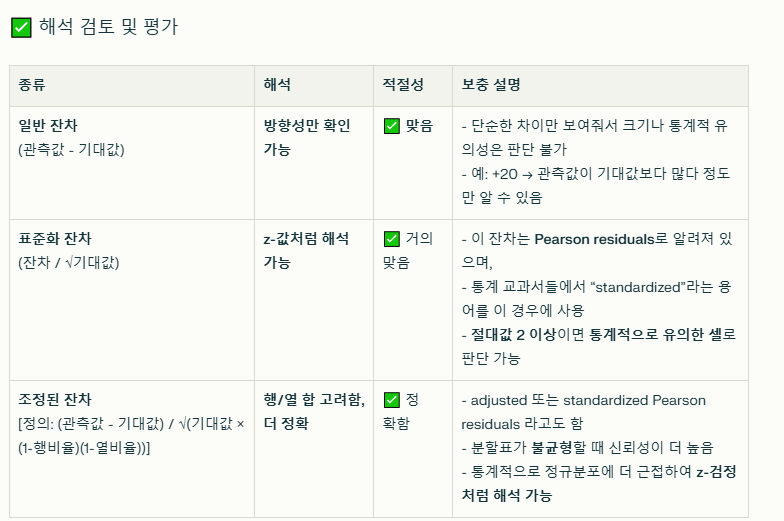


- 일반잔차: 단순비교
- 표준화잔차: 빠른 유의성 판단
- 조정된 잔차: 교차표에서 유의한 셀 식별

**이 문제에서는 검정결과에 대한 유의성을 확인하기 위해 표준화 잔차를 수행한다.**

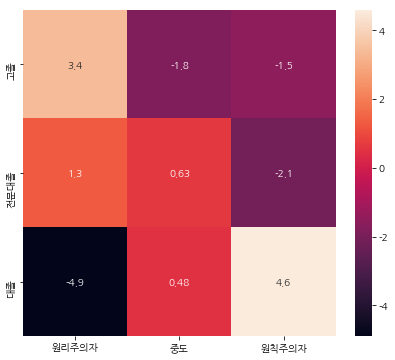

In [63]:
s_residual = (dd - expected)/np.sqrt(expected)

s_residual = pd.DataFrame(s_residual, index=dt5.index, columns=dt5.columns)
plt.figure(figsize=(7, 6))
sns.heatmap(s_residual, annot=True)
plt.show()

표준화 잔차의 절대값이 2 이상이면 통계적으로 유의한 셀이므로,
- (원리주의자-대졸: 음의 상관관계), (원리주의자-고졸: 양의 상관관계) 
- (원칙주의자-전문대졸: 음의 상관관계), (원칙주의자-대졸: 양의 상관관계)  
이 통계적으로 유의함을 확인할 수 있다.



## 문제 6

슬통 초등학교에서는 학생들의 건강 관리를 위해 일부 학생들의 혈압을 측정하였습니다. 총 25명의 학생 중 남학생은 16명, 여학생은 9명이었습니다. 학교 건강 관리팀은 남학생과 여학생 사이에 평균 혈압이 차이가 있는지 궁금해하였고, 이를 확인하기 위해 5%의 유의수준에서 검정하려 합니다. (단, 남녀 학생의 혈압이 정규분포를 따르며, 두 집단의 분산이 동일하다고 가정합니다.)  
**모수검정: 독립 이표본 ttest(분산동일)**

In [67]:
dt6 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/26/problem6.csv')
dt6

,No.,남학생,여학생
0,1,124.97,114.87
1,2,118.62,128.14
2,3,126.48,115.92
3,4,135.23,110.88
4,5,117.66,139.66
5,6,117.66,122.74
6,7,135.79,125.68
7,8,127.67,110.75
8,9,115.31,119.56
9,10,125.43,NaN


1)  **연구가설과 귀무가설 작성하시오.**


- H0: 남학생과 여학생의 평균혈압의 차이가 없다.
- H1: 남학생과 여학생의 평균혈압의 차이가 있다.


2)  **가설검증에 대한 검정통계량을 계산하고, 연구가설의 채택여부를 설명하시오.**

In [77]:
from scipy.stats import ttest_ind

g1 = dt6['남학생']
g2 = dt6['여학생'].dropna()

stat, p = ttest_ind(g1, g2, equal_var=True)

print(f"t 통계량: {stat:.3f}")
print(f"p-value: {p:.3f}, 유의수준 5% 하에서 귀무가설을", "기각" if p < 0.05 else "기각x")

t 통계량: -0.292
p-value: 0.773, 유의수준 5% 하에서 귀무가설을 기각x


독립 2표본 t검정(등분산 가정) 결과, 유의수준 5% 하에서 p-value가 0.773으로 충분히 크므로  
귀무가설을 기각할 수 없다.  
따라서 남학생과 여학생 간 평균혈압의 차이는 없다. 

3)  **가설검정에 대한 신뢰구간을 계산하고, 계산된 신뢰구간이 어떻게 2의 결과를 지지하는지 설명하시오.
    (단, 신뢰구간 계산시 다음의 값을 사용하시오.)**

-   $t_{23,0.025} = 2.069$
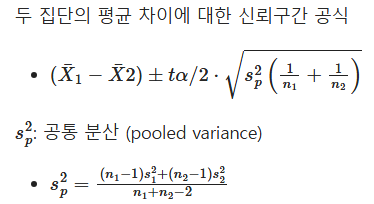

In [81]:
ta = 2.069 # 단측 t 값
d_mean = g1.mean() - g2.mean() #평균의 차
dof1 = len(g1) - 1
dof2 = len(g2) -1
var1 = g1.var(ddof=1)
var2 = g2.var(ddof=1)

sp_var = ((dof1*var1)+(dof2*var2))/(dof1+dof2)
e_limit = ta*np.sqrt(sp_var*((1/len(g1))+(1/len(g2))))

down = d_mean - e_limit
up = d_mean + e_limit

print(f"유의수준 5% 하 신뢰구간은 {down:.3f} ~ {up:.3f}")

유의수준 5% 하 신뢰구간은 -9.424 ~ 7.095


두 집단의 실제 평균 차이(모평균 차이)가 -9.424 ~ 7.095 범위 안에 있을 가능성이 95%임  
신뢰구간 내 0이 포함되어 있으므로 두 그룹의 평균 차이가 유의하지 않다고 볼 수 있다.

| 신뢰구간 범위  | 유의성 해석               |
| -------- | -------------------- |
| `둘 다 양수` | **g1 > g2** 통계적으로 유의 |
| `둘 다 음수` | **g1 < g2** 통계적으로 유의 |
| `0 포함`   | 평균 차이 **유의하지 않음**    |
